In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/flights[1].csv')
df

/tmp/ipykernel_6194/3615033733.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/flights[1].csv')


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# Milestone 1: Data Foundation and Cleaning

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [5]:
columns_to_drop = ['TAXI_IN', 'TAXI_OUT', 'WHEELS_ON', 'WHEELS_OFF']
df = df.drop(columns=columns_to_drop, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 27 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  SCHEDULED_TIME       float64
 13  ELAPSED_TIME         float64
 14  AIR_TIME             float64
 15  DISTANCE             int64  
 16  SCHEDULED_ARRIVAL    int64  
 17  ARRIVAL_TIME         float64
 18  ARRIVAL_DELAY        float64
 19  DIVERTED             int64  
 20  CANCELLED            int64  
 21  CANCELLATION_REASON  object 
 22  AIR_SYSTEM_DELAY     float64
 23  SECURITY_DELAY       float64
 24

In [6]:
df.isnull().sum()

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,14721
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [7]:
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna('Not Cancelled')


In [8]:
df['TAIL_NUMBER'] = df['TAIL_NUMBER'].fillna('Unknown')


In [9]:
delay_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
df[delay_columns] = df[delay_columns].fillna(0)

time_delay_columns = ['DEPARTURE_TIME', 'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'ARRIVAL_TIME', 'ARRIVAL_DELAY']
for col in time_delay_columns:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,0
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [10]:
# Map numbers to day names
day_map = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_map)
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DAY_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,-26.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,-16.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,-8.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,-10.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0,Thursday


In [11]:
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100
df[['SCHEDULED_DEPARTURE', 'HOUR']].head()


,SCHEDULED_DEPARTURE,HOUR
0,5,0
1,10,0
2,20,0
3,20,0
4,25,0


In [12]:
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + '-' + df['DESTINATION_AIRPORT'].astype(str)
df[['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,ANC,SEA,ANC-SEA
1,LAX,PBI,LAX-PBI
2,SFO,CLT,SFO-CLT
3,LAX,MIA,LAX-MIA
4,SEA,ANC,SEA-ANC


In [13]:
# Re-add 'ROUTE' column
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + '-' + df['DESTINATION_AIRPORT'].astype(str)
print("'ROUTE' column added.")

'ROUTE' column added.


In [14]:
print(f"Final DataFrame shape: {df.shape}")

Final DataFrame shape: (5819079, 30)


In [15]:
df.to_csv('/content/flights_cleaned.csv', index=False)
print("DataFrame saved to '/content/flights_cleaned.csv'")

DataFrame saved to '/content/flights_cleaned.csv'


# MILESTONE ***2***

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

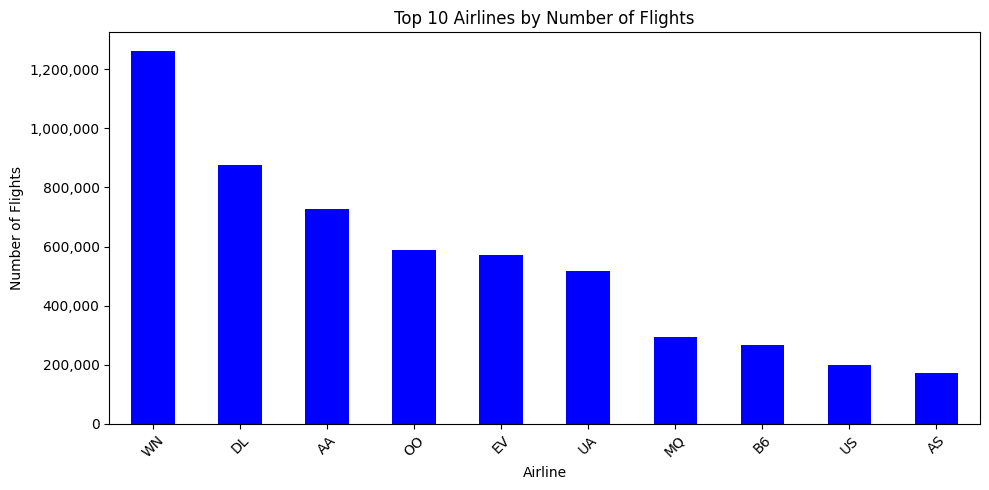

In [17]:


# Top 10 Airlines by Number of Flights
top_airlines = df['AIRLINE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_airlines.plot(kind='bar',color='blue')

plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')

# Remove decimals
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

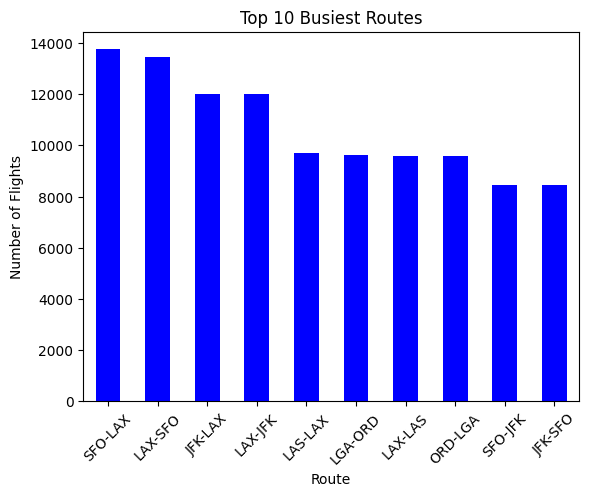

In [18]:
df['ROUTE'].value_counts().head(10).plot(kind='bar',color = 'blue')

plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)
plt.show()

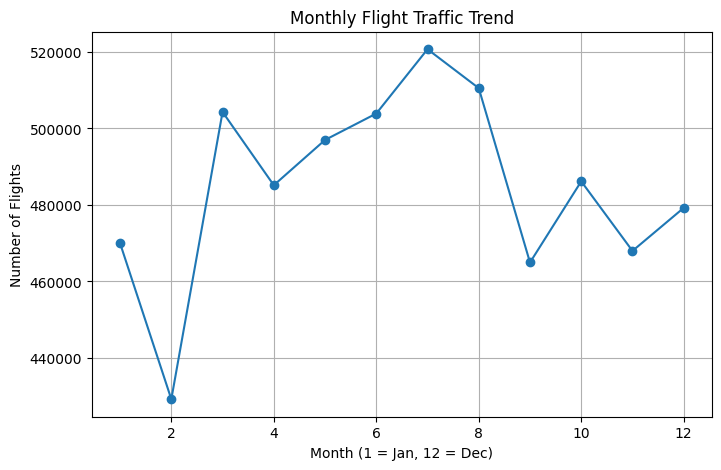

In [19]:
plt.figure(figsize=(8,5))

monthly_flights = df['MONTH'].value_counts().sort_index()

plt.plot(monthly_flights.index, monthly_flights.values, marker='o')

plt.title("Monthly Flight Traffic Trend")
plt.xlabel("Month (1 = Jan, 12 = Dec)")
plt.ylabel("Number of Flights")

plt.grid(True)   # grid add chesthundi clarity kosam

plt.show()

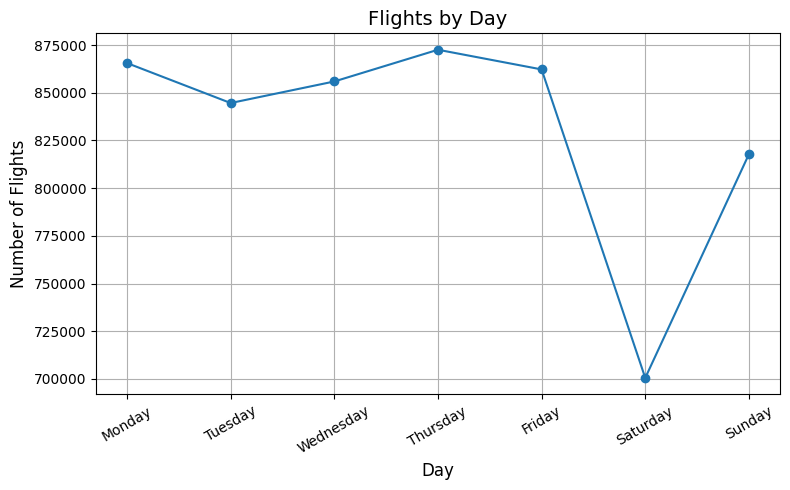

In [20]:
plt.figure(figsize=(8,5))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_flights = df['DAY_NAME'].value_counts().reindex(day_order)

plt.plot(day_flights.index, day_flights.values, marker='o')

plt.title("Flights by Day", fontsize=14)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

plt.xticks(rotation=30)
plt.grid(True)

plt.tight_layout()
plt.show()

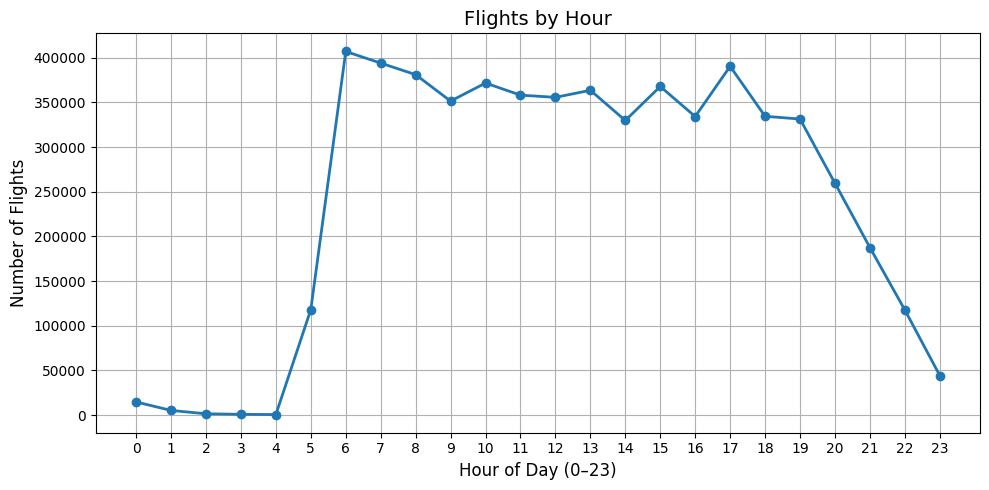

In [21]:

# Count flights by hour
hour_flights = df['HOUR'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(hour_flights.index,
         hour_flights.values,
         marker='o',
         linewidth=2)

plt.title("Flights by Hour", fontsize=14)
plt.xlabel("Hour of Day (0–23)", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

plt.xticks(range(0,24))
plt.grid(True)

plt.tight_layout()
plt.show()

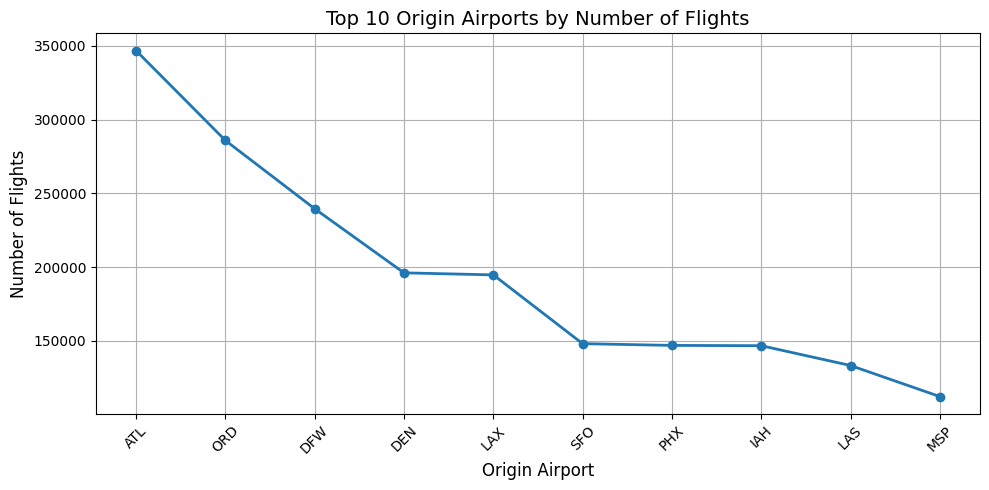

In [22]:
# Count flights by origin airport
airport_flights = df['ORIGIN_AIRPORT'].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.plot(airport_flights.index,
         airport_flights.values,
         marker='o',
         linewidth=2)

plt.title("Top 10 Origin Airports by Number of Flights", fontsize=14)
plt.xlabel("Origin Airport", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

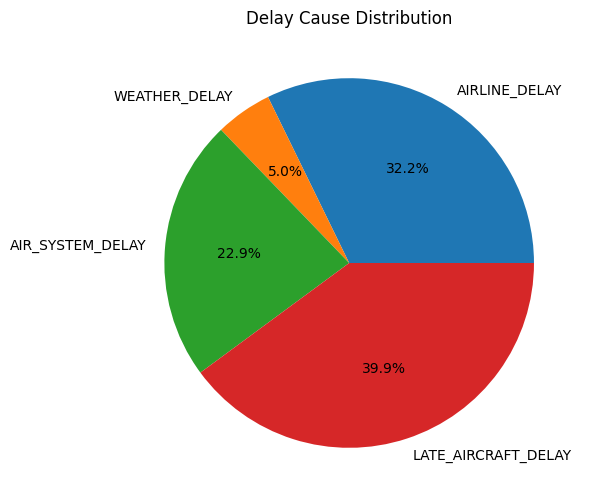

In [23]:
delay_cols = ['AIRLINE_DELAY', 'WEATHER_DELAY',
              'AIR_SYSTEM_DELAY', 'LATE_AIRCRAFT_DELAY']

delay_sum = df[delay_cols].sum()

plt.figure(figsize=(6,6))

plt.pie(delay_sum, labels=delay_cols, autopct='%1.1f%%')

plt.title("Delay Cause Distribution")
plt.show()


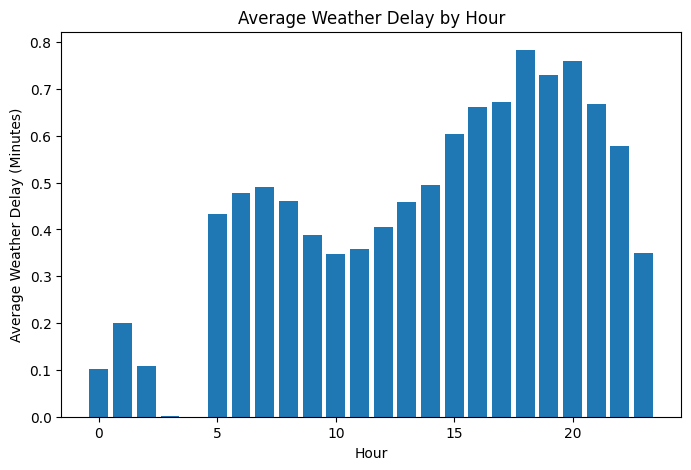

In [24]:
weather_hour = df.groupby('HOUR')['WEATHER_DELAY'].mean()

plt.figure(figsize=(8,5))
plt.bar(weather_hour.index, weather_hour.values)

plt.title("Average Weather Delay by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Weather Delay (Minutes)")

plt.show()

Average NAS Delay: 2.4635792021383454


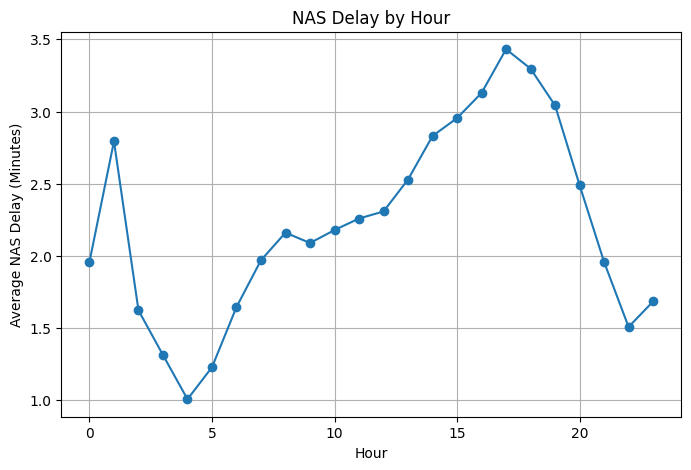

In [25]:
# NAS Delay Analysis

# Average
nas_avg = df['AIR_SYSTEM_DELAY'].mean()
print("Average NAS Delay:", nas_avg)

# By Hour
nas_hour = df.groupby('HOUR')['AIR_SYSTEM_DELAY'].mean()

plt.figure(figsize=(8,5))
plt.plot(nas_hour.index, nas_hour.values, marker='o')

plt.title("NAS Delay by Hour")
plt.xlabel("Hour")
plt.ylabel("Average NAS Delay (Minutes)")
plt.grid(True)
plt.show()

Average Carrier Delay: 3.46669223772353


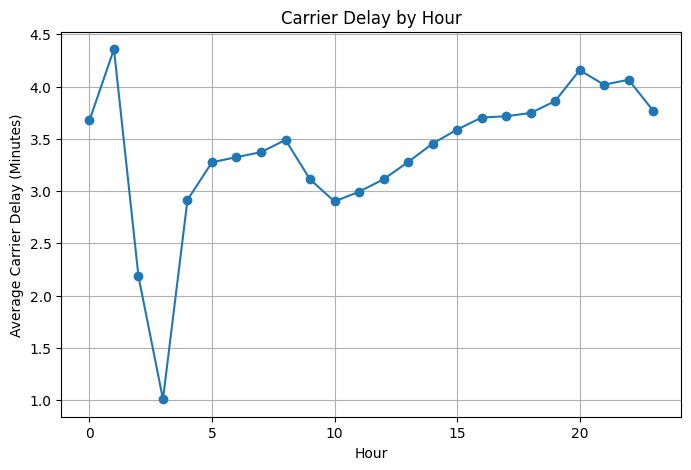

In [26]:
# Carrier Delay Analysis

# Average
carrier_avg = df['AIRLINE_DELAY'].mean()
print("Average Carrier Delay:", carrier_avg)

# By Hour
carrier_hour = df.groupby('HOUR')['AIRLINE_DELAY'].mean()

plt.figure(figsize=(8,5))
plt.plot(carrier_hour.index, carrier_hour.values, marker='o')

plt.title("Carrier Delay by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Carrier Delay (Minutes)")
plt.grid(True)
plt.show()

# Milestone 3: Route, Cancellation, and Seasonal Insights

/tmp/ipykernel_6194/1082539895.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')


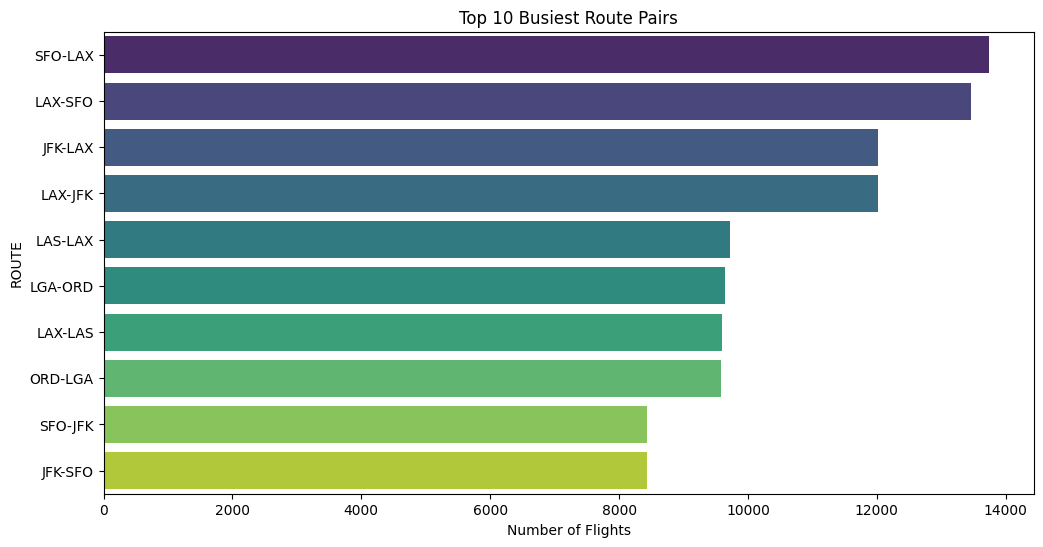

In [27]:

## 1.1 Top 10 Origin-Destination Pairs
plt.figure(figsize=(12, 6))

top_routes = df['ROUTE'].value_counts().head(10)
sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')
plt.title('Top 10 Busiest Route Pairs')
plt.xlabel('Number of Flights')
plt.show()



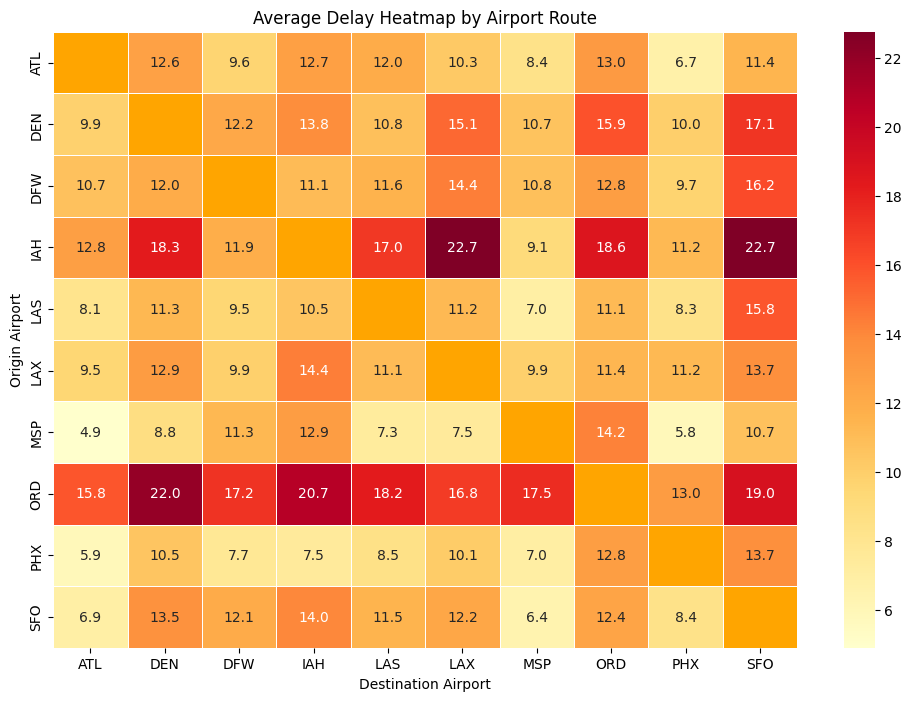

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Top 10 airports
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10).index

df_top = df[df['ORIGIN_AIRPORT'].isin(top_airports) &
            df['DESTINATION_AIRPORT'].isin(top_airports)]

# Pivot table
route_delay = df_top.pivot_table(
    values='DEPARTURE_DELAY',
    index='ORIGIN_AIRPORT',
    columns='DESTINATION_AIRPORT',
    aggfunc='mean'
)

# Color map change
cmap = plt.cm.YlOrRd
cmap.set_bad(color='orange')   # white place lo new color

plt.figure(figsize=(12,8))

sns.heatmap(route_delay,
            cmap=cmap,
            annot=True,
            fmt=".1f",
            linewidths=0.5)

plt.title("Average Delay Heatmap by Airport Route")
plt.xlabel("Destination Airport")
plt.ylabel("Origin Airport")

plt.show()

In [29]:
import pandas as pd
import plotly.express as px

# -------- Maps showing busiest airports and average delays --------

# Airport statistics
airport_stats = df.groupby("ORIGIN_AIRPORT").agg(
    Flights=("ORIGIN_AIRPORT", "count"),
    Avg_Delay=("ARRIVAL_DELAY", "mean")
).reset_index()

# Top busiest airports
top_airports = airport_stats.sort_values("Flights", ascending=False).head(15)

# Airport coordinates
coords = {
'ATL':[33.64,-84.42],'LAX':[33.94,-118.40],'ORD':[41.97,-87.90],
'DFW':[32.89,-97.04],'DEN':[39.85,-104.67],'JFK':[40.64,-73.77],
'SFO':[37.62,-122.37],'SEA':[47.45,-122.30],'LAS':[36.08,-115.15],
'MCO':[28.43,-81.30],'EWR':[40.68,-74.17],'CLT':[35.21,-80.94],
'PHX':[33.43,-112.01],'IAH':[29.99,-95.33],'MIA':[25.79,-80.28]
}

# Add coordinates
top_airports["lat"] = top_airports["ORIGIN_AIRPORT"].map(lambda x: coords.get(x,[None,None])[0])
top_airports["lon"] = top_airports["ORIGIN_AIRPORT"].map(lambda x: coords.get(x,[None,None])[1])

# Create map
fig = px.scatter_geo(
    top_airports,
    lat="lat",
    lon="lon",
    size="Flights",
    color="Avg_Delay",
    hover_name="ORIGIN_AIRPORT",
    projection="natural earth",
    color_continuous_scale="Plasma",
    title="Map of Busiest Airports and Average Arrival Delays"
)

# Improve map visuals
fig.update_geos(
    showland=True,
    landcolor="lightgreen",
    showocean=True,
    oceancolor="lightblue",
    showlakes=True,
    lakecolor="lightblue",
    showcountries=True,
    countrycolor="black"
)

fig.show()

# -------- Observations --------
busiest = top_airports.loc[top_airports["Flights"].idxmax()]
highest_delay = top_airports.loc[top_airports["Avg_Delay"].idxmax()]
lowest_delay = top_airports.loc[top_airports["Avg_Delay"].idxmin()]
corr = airport_stats["Flights"].corr(airport_stats["Avg_Delay"])

print("\nObservations:\n")
print(f"1. {busiest['ORIGIN_AIRPORT']} is the busiest airport with {busiest['Flights']} flights.")
print(f"2. {highest_delay['ORIGIN_AIRPORT']} has the highest average delay ({highest_delay['Avg_Delay']:.2f} minutes).")
print(f"3. {lowest_delay['ORIGIN_AIRPORT']} has the lowest average delay ({lowest_delay['Avg_Delay']:.2f} minutes).")
print(f"4. Correlation between airport traffic and delay: {corr:.2f}")
print("5. Larger bubbles indicate busier airports, while brighter colors represent higher delays.")


Observations:

1. ATL is the busiest airport with 346836 flights.
2. ORD has the highest average delay (8.16 minutes).
3. MSP has the lowest average delay (1.90 minutes).
4. Correlation between airport traffic and delay: 0.07
5. Larger bubbles indicate busier airports, while brighter colors represent higher delays.


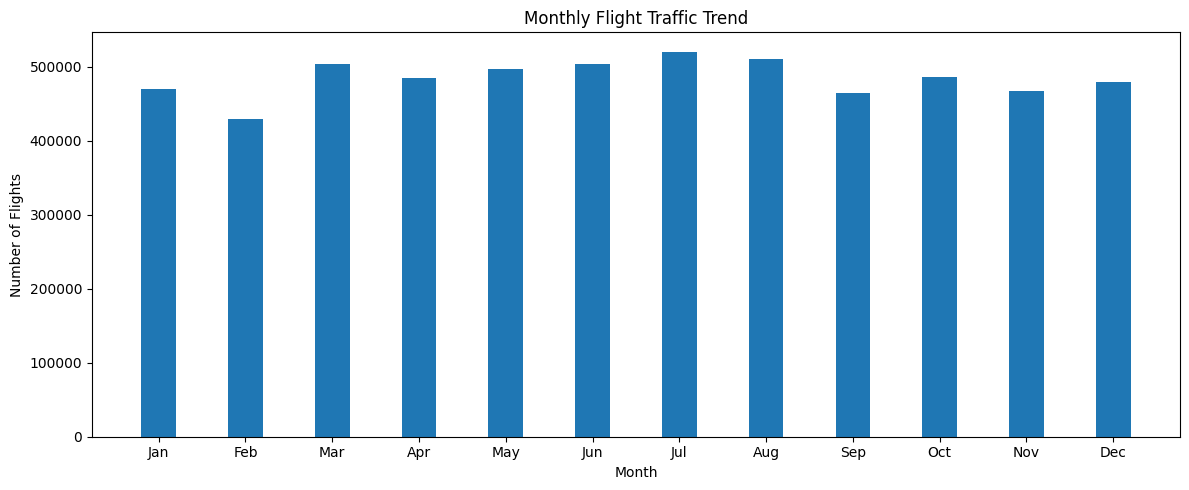

In [30]:
import matplotlib.pyplot as plt

# Flights per month
monthly_flights = df['MONTH'].value_counts().sort_index()

# X and Y values
x = monthly_flights.index
y = monthly_flights.values

plt.figure(figsize=(12,5))

# Thin bars
plt.bar(x, y, width=0.4)


# Month labels
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

plt.xticks(range(1,13), months)

plt.title("Monthly Flight Traffic Trend")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()

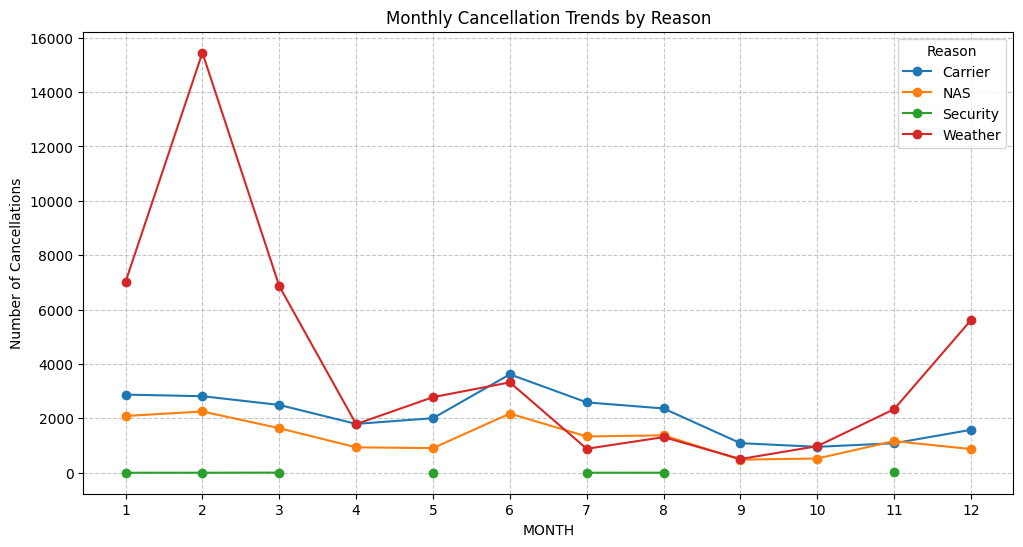

--- Milestone 3 Insights ---
Route with highest avg delay: IAD-TTN
Month with most weather cancellations: 2


In [31]:

reason_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
df['CANCELLATION_REASON_LABEL'] = df['CANCELLATION_REASON'].map(reason_map)

plt.figure(figsize=(12, 6))
monthly_cancel = df[df['CANCELLED'] == 1].groupby(['MONTH', 'CANCELLATION_REASON_LABEL']).size().unstack()
monthly_cancel.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Monthly Cancellation Trends by Reason')
plt.ylabel('Number of Cancellations')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Reason')
plt.show()



# --- SECTION 3: Summary Statistics for Presentation ---
print("--- Milestone 3 Insights ---")
print(f"Route with highest avg delay: {df.groupby('ROUTE')['ARRIVAL_DELAY'].mean().idxmax()}")
print(f"Month with most weather cancellations: {df[df['CANCELLATION_REASON'] == 'B']['MONTH'].mode()[0]}")

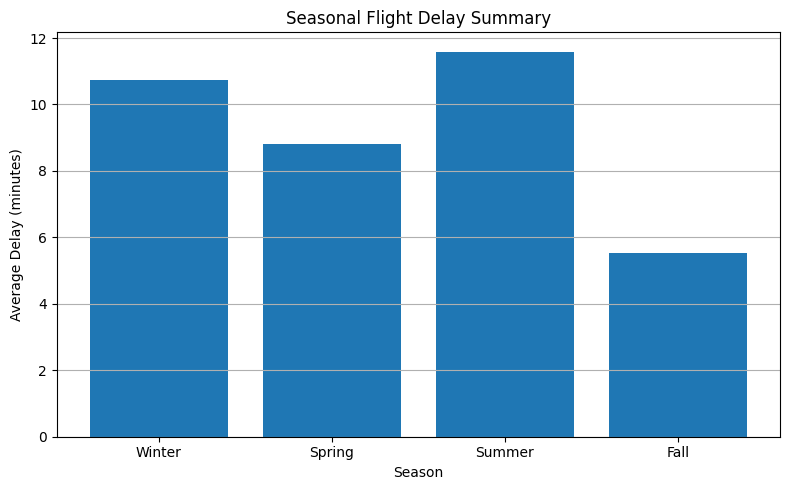

In [32]:
import matplotlib.pyplot as plt

# Season mapping
season_map = {
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Fall', 10:'Fall', 11:'Fall'
}

# Create season column
df['SEASON'] = df['MONTH'].map(season_map)

# Average delay per season
season_delay = df.groupby('SEASON')['DEPARTURE_DELAY'].mean()

# Order seasons correctly
season_order = ['Winter','Spring','Summer','Fall']
season_delay = season_delay.reindex(season_order)

plt.figure(figsize=(8,5))

plt.bar(season_delay.index,
        season_delay.values)

plt.title("Seasonal Flight Delay Summary")
plt.xlabel("Season")
plt.ylabel("Average Delay (minutes)")

plt.grid(axis='y')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6194/3157448040.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




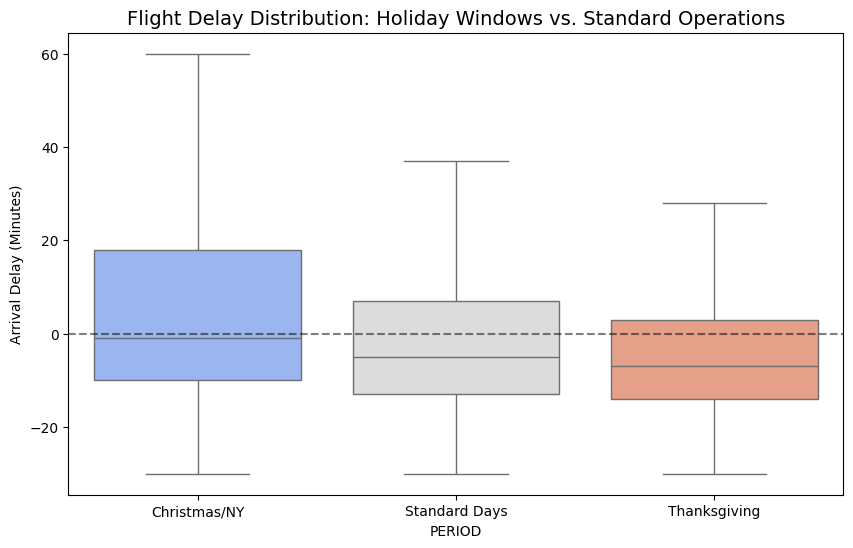

In [33]:

# 1. Define Holiday Windows
def label_travel_period(row):
    # Thanksgiving: Approx Nov 23 - Nov 30
    if row['MONTH'] == 11 and (23 <= row['DAY'] <= 30):
        return 'Thanksgiving'
    # Christmas/New Year: Dec 20 - Jan 3
    elif (row['MONTH'] == 12 and row['DAY'] >= 20) or (row['MONTH'] == 1 and row['DAY'] <= 3):
        return 'Christmas/NY'
    else:
        return 'Standard Days'

# 2. Apply and Plot
df['PERIOD'] = df.apply(label_travel_period, axis=1)

plt.figure(figsize=(10, 6))
# Boxplot shows the distribution and extreme outliers (delays)
sns.boxplot(x='PERIOD', y='ARRIVAL_DELAY', data=df[df['ARRIVAL_DELAY'].between(-30, 150)],
            palette='coolwarm', showfliers=False)

plt.title('Flight Delay Distribution: Holiday Windows vs. Standard Operations', fontsize=14)
plt.ylabel('Arrival Delay (Minutes)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
df.to_csv("cleaned_flights.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_flights.csv")